# Tutorial de matrices con SymPy y Diagramas con NetworkX
### Peña Hernández Carlo Gael
En este notebook tutorial se abordan las operaciones fundamentales de álgebra lineal (entradas de matrices, y multiplicaciones) usando la librería ***sympy*** que permite hacer cálculos simbólicos, y cómo visualizar un diagrama de transición de estados (Para cadenas de Markov) usando ***networkx***.

## 1. Representar Matrices en SymPy

Para crear una matriz, se usa la función `sympy.Matrix(Argumento)`. En su argumento debe ir una lista donde cada elemento es otra lista, cada 'sublista' representa un renglón de la matriz.

Se definen dos matrices $A$, $B$ y se muestran simbolicamente con el comando `display()` o `pprint()` (Pretty print).
`display()` renderiza un código en $\LaTeX$, y `pprint()` solo imprime con caracteres ASCII de forma ordenada para que se vea mejor

In [15]:
import sympy as sp

# Matriz A de 2x2
A = sp.Matrix([[1, 2], [3, 4]])

# Matriz B de 2x2
B = sp.Matrix([[1, 0], [-1, 2]])

display("Matriz A:", A)
print("\nMatriz B:")
sp.pprint(B)

'Matriz A:'

⎡1  2⎤
⎢    ⎥
⎣3  4⎦

⎡           ⎡1   0⎤⎤
⎢Matriz B:, ⎢     ⎥⎥
⎣           ⎣-1  2⎦⎦


## 2. Obtener Entradas Específicas

En Python, los índices comienzan en 0. 
Para obtener un renglón, columna o entrada específica se puede hacer de varias formas:
* Para obtener un renglón: `matriz.row(índice)` o `matriz[índice,:]`
* Para obtener una columna: `matriz.col(índice)` o `matriz[:,índice]`
* Para una entrada específica: `matriz[renglón, columna]`
* Donde `matriz` es el nombre del objeto en donde está guardada la matriz (Que antes se definió con `sympy.Matrix()`), en este ejemplo podría ser la matriz `A` o `B`

In [11]:
renglon_1 = A.row(0) # Renglón 1 de A (índice 0 de python)
columna_2 = A.col(1) # Columna 2 de B (índice 1 de python)
entrada_21 = A[1, 0] # Renglón 2, Columna 1 de A (el número 3)

display("Primer renglón:", renglon_1)
display("Segunda columna:", columna_2)
display("Renglón 2, Columna 1:", entrada_21)

[3  4]

'Primer renglón:'

[1  2]

'Segunda columna:'

⎡2⎤
⎢ ⎥
⎣4⎦

'Renglón 2, Columna 1:'

3

## 3. Multiplicación y Potencias de Matrices

Para multiplicar matrices ($A\cdot B$ o simplemente $AB$) se usa el operador `*`, o la función `sympy.MatMul(A,B)`. Para elevar una matriz a una potencia n-ésima ($\displaystyle A^n=\prod_{i=1}^{n}A$) se usa `**` o la función `sympy.MatPow(A,n)`, al igual que con números.

In [9]:
AB = A * B
B3 = B**3 # Multiplicar A por sí misma 3 veces

display("AB:", AB)
print()
display("A3:", A3)

'AB:'

⎡-1  4⎤
⎢     ⎥
⎣-1  8⎦

'A3:'

⎡37  54 ⎤
⎢       ⎥
⎣81  118⎦

## 4. Multiplicación de Vectores por Matrices

En SymPy, un vector suele representarse como una matriz de una sola columna. Para multiplicar una matriz por un vector $A \cdot \vec{v}$, la matriz debe estar a la izquierda y el vector a la derecha, de otro modo, el producto no está definido.
Para multiplicar un 'vector' horizontal por una matriz, el vector debe estar a la izquierda y la matriz a la derecha, ese vector se representa como un vector **transpuesto**, eso se hace con la función `sympy.Transponse(vector)` o `sympy.transponse(vector)` o `vector.T`. La transposición tambien se puede aplicar a las matrices de la misma forma.

In [18]:
# Vector columna de 2x1
v = sp.Matrix([2, -1]) 

producto_matriz_vector = A * v

display("Vector v:", v)
print()
display("A*v:", producto_matriz_vector)

'Vector v:'

⎡2 ⎤
⎢  ⎥
⎣-1⎦

'A*v:'

⎡0⎤
⎢ ⎥
⎣2⎦

## 5. Valores y Vectores Propios

* `matriz.eigenvals()`: Devuelve un diccionario con el valor propio como clave (key) y su multiplicidad algebraica como valor (value).
* `matriz.eigenvects()`: Devuelve una lista de tuplas (listas inmutables) con el formato `(valor_propio, multiplicidad, [vectores_propios])`.

In [19]:
valores_propios = A.eigenvals()
vectores_propios = A.eigenvects()

print("Valores propios (Formato: {valor: multiplicidad}):")
display(valores_propios)

print("\nVectores propios:")
display(vectores_propios)

Valores propios (Formato: {valor: multiplicidad}):


⎧5   √33     5   √33   ⎫
⎨─ - ───: 1, ─ + ───: 1⎬
⎩2    2      2    2    ⎭


Vectores propios:


⎡⎛            ⎡⎡  √33   1⎤⎤⎞  ⎛            ⎡⎡  1   √33⎤⎤⎞⎤
⎢⎜5   √33     ⎢⎢- ─── - ─⎥⎥⎟  ⎜5   √33     ⎢⎢- ─ + ───⎥⎥⎟⎥
⎢⎜─ - ───, 1, ⎢⎢   6    2⎥⎥⎟, ⎜─ + ───, 1, ⎢⎢  2    6 ⎥⎥⎟⎥
⎢⎜2    2      ⎢⎢         ⎥⎥⎟  ⎜2    2      ⎢⎢         ⎥⎥⎟⎥
⎣⎝            ⎣⎣    1    ⎦⎦⎠  ⎝            ⎣⎣    1    ⎦⎦⎠⎦

## 6. Diagramas de Transición con NetworkX

Un diagrama de transición se puede representar como un **grafo dirigido** (`DiGraph`) por "*Directed Graph*". Los nodos son los estados y las aristas (flechas) representan la transición, llevando un peso o probabilidad.
En la función se irán añadiendo los elementos del diagrama como los nodos y aristas.
Luego, se grafica con la librería graphviz
A pesar de que Networkx tiene su propia forma de graficar, es más útil y con menos errores hacerlo en graphviz.

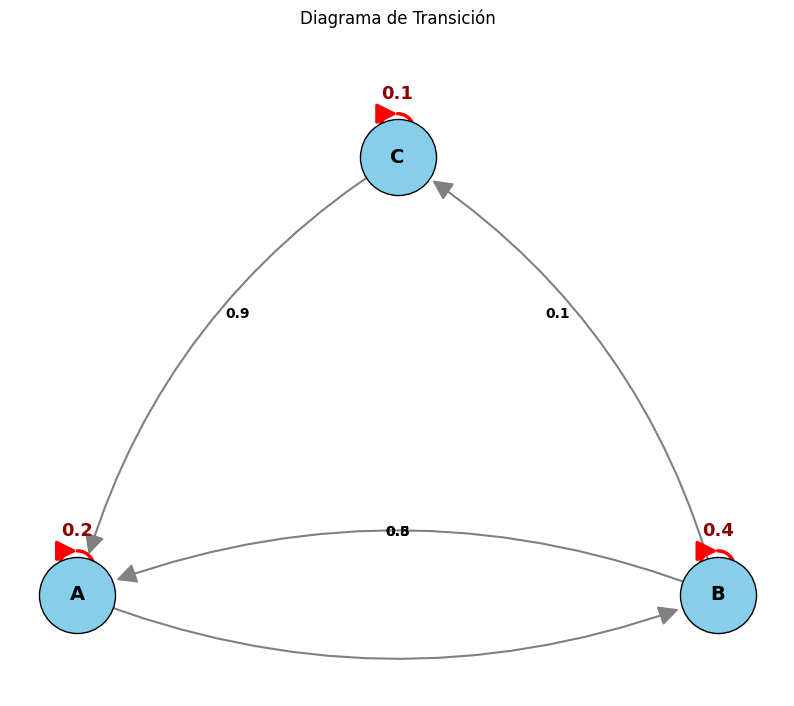

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Configuración del Grafo
G = nx.DiGraph()
edges = [
    ('A', 'A', 0.2), ('A', 'B', 0.8),
    ('B', 'A', 0.5), ('B', 'B', 0.4),
    ('B', 'C', 0.1), ('C', 'A', 0.9),
    ('C', 'C', 0.1)
]
G.add_weighted_edges_from(edges)

# Posiciones
pos = {'A': (0, 0), 'B': (2, 0), 'C': (1, 1.5)} 

plt.figure(figsize=(10, 8))

# 2. Dibujar Nodos
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# 3. Aristas entre nodos (Grises y Curvas)
out_edges = [(u, v) for u, v in G.edges() if u != v]
nx.draw_networkx_edges(
    G, pos, edgelist=out_edges, 
    connectionstyle="arc3, rad=0.2", 
    arrowsize=30, edge_color='gray', width=1.5,
    min_target_margin=30  # Esto hace que se vea la punta de la flecha
)

# 4. BUCLES (Forzando tamaño con "bar" o "arc" de gran radio)
self_loops = [(u, v) for u, v in G.edges() if u == v]
for u, v in self_loops:
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        # Usamos 'arc' con un ángulo de salida/entrada muy abierto y brazos largos
        connectionstyle="arc, angleA=-60, angleB=60, armA=70, armB=70, rad=30",
        arrowsize=30, edge_color='red', width=2.5,
        min_target_margin=20
    )

# 5. Etiquetas de Probabilidad (Texto)
edge_labels = nx.get_edge_attributes(G, 'weight')
for (u, v), label in edge_labels.items():
    if u == v:
        # Colocamos el texto justo donde termina el bucle grande
        plt.text(pos[u][0], pos[u][1] + 0.2, label, 
                 color='darkred', weight='bold', ha='center', fontsize=13)
    else:
        # Punto medio para aristas normales
        x = (pos[u][0] + pos[v][0]) / 2
        y = (pos[u][1] + pos[v][1]) / 2
        plt.text(x, y + 0.2, label, color='black', weight='bold', ha='center')



plt.title("Diagrama de Transición", pad=40)
plt.axis('off')
plt.show()